In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

In [5]:
import pandas as pd

df = pd.read_pickle("../results/preprocessed.pkl")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (50000, 3)


,review,sentiment,cleaned
0,One of the other reviewers has mentioned that ...,positive,"[one, reviewer, mentioned, watching, oz, episo..."
1,A wonderful little production. <br /><br />The...,positive,"[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,"[basically, family, little, boy, jake, think, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, mattei, love, time, money, visually, ..."


In [59]:
import sys
import os
import scipy.sparse
import pickle

sys.path.append(os.path.abspath(".."))

from vectorization.bow import get_bow_vectorizer, vectorize as bow_vectorize
from vectorization.tfidf import get_tfidf_vectorizer, vectorize as tfidf_vectorize

bow_vectorizer = get_bow_vectorizer()
X_bow = bow_vectorize(df, bow_vectorizer)

tfidf_vectorizer = get_tfidf_vectorizer()
X_tfidf = tfidf_vectorize(df, tfidf_vectorizer)

os.makedirs("../results", exist_ok=True)

# sparse matrice u .npz formatu zbog memorije 
scipy.sparse.save_npz("../results/X_bow.npz", X_bow)
scipy.sparse.save_npz("../results/X_tfidf.npz", X_tfidf)

with open("../results/bow_vectorizer.pkl", "wb") as f:
    pickle.dump(bow_vectorizer, f)

with open("../results/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("\nMatrices saved as .npz (sparse format)")
print("Vectorizers saved as .pkl (pickle format)")


Matrices saved as .npz (sparse format)
Vectorizers saved as .pkl (pickle format)


In [25]:
print("BoW matrix shape:", X_bow.shape)
print("TF-IDF matrix shape:", X_tfidf.shape)

BoW matrix shape: (50000, 89220)
TF-IDF matrix shape: (50000, 89220)


In [34]:
word_counts = np.asarray(X_bow.sum(axis=0)).flatten()

words = bow_vectorizer.get_feature_names_out()

count_df = pd.DataFrame({
    'word': words,
    'count': word_counts
})

count_df = count_df.sort_values(by='count', ascending=False)

bow_top_20= count_df.head(20)

bow_top_20

,word,count
52273,movie,99813
28061,film,90383
55800,one,53019
45556,like,39975
79375,time,29643
32396,good,28794
12883,character,27736
87725,would,26454
25921,even,24517
31418,get,24449


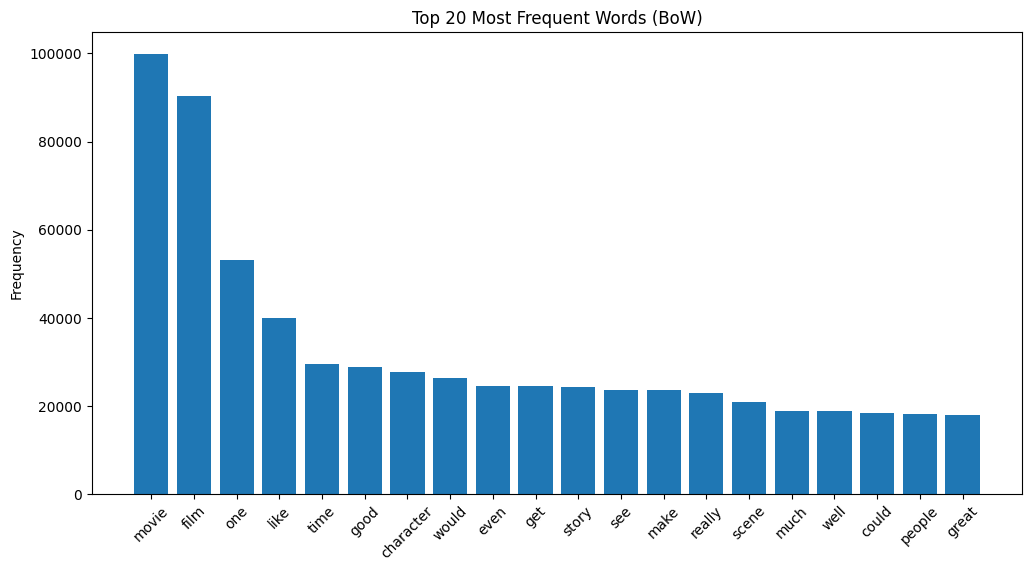

In [37]:
plt.figure(figsize=(12,6))

plt.bar(bow_top_20['word'], bow_top_20['count'])

plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (BoW)")
plt.ylabel("Frequency")

plt.show()

In [52]:
word_scores = np.asarray(X_tfidf.mean(axis=0)).flatten()

words = tfidf_vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    'word': words,
    'tfidf_score': word_scores
})

freq_df = freq_df.sort_values(by='tfidf_score', ascending=False)

top_tfidf= freq_df.head(20)

top_tfidf

,word,tfidf_score
52273,movie,0.053216
28061,film,0.043903
55800,one,0.026393
45556,like,0.022685
32396,good,0.019865
79375,time,0.018690
12883,character,0.017944
87725,would,0.017574
75105,story,0.017328
63828,really,0.017178


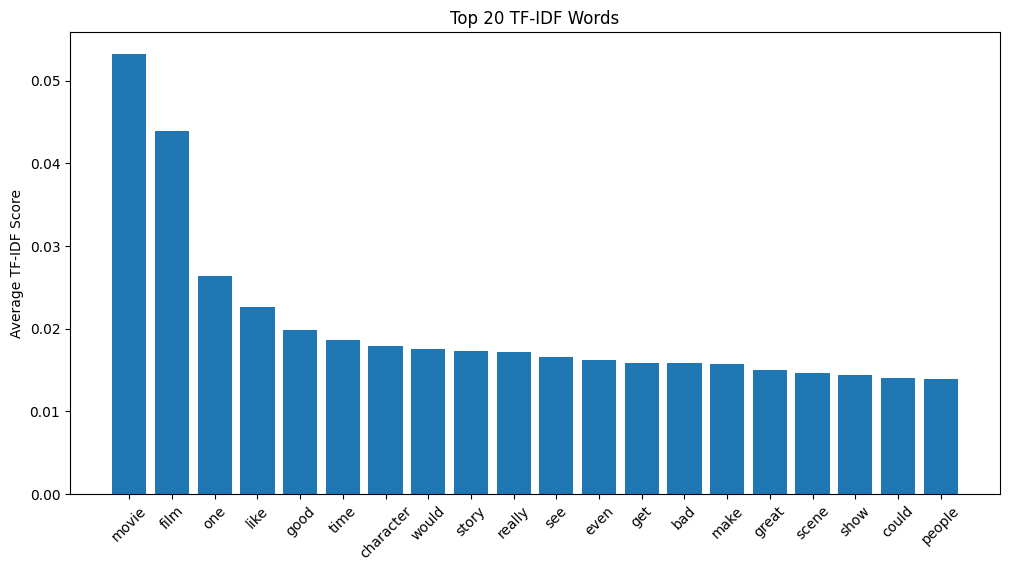

In [54]:
plt.figure(figsize=(12,6))

plt.bar(top_tfidf['word'], top_tfidf['tfidf_score'])

plt.xticks(rotation=45)
plt.title("Top 20 TF-IDF Words")
plt.ylabel("Average TF-IDF Score")

plt.show()

In [56]:
selected_words = bow_top_20.head(10)['word'].tolist()
selected_word_indices = [
    bow_vectorizer.vocabulary_[word]
    for word in selected_words
]

print(selected_word_indices)

print(selected_words)

[52273, 28061, 55800, 45556, 79375, 32396, 12883, 87725, 25921, 31418]
['movie', 'film', 'one', 'like', 'time', 'good', 'character', 'would', 'even', 'get']


In [57]:
bow_subset = pd.DataFrame(
    X_bow[:5, selected_word_indices].toarray(),
    columns=selected_words
)

bow_subset.index = [f"Review {i}" for i in range(1, 6)]

bow_subset

,movie,film,one,like,time,good,character,would,even,get
Review 1,0,0,1,0,0,0,0,2,0,2
Review 2,0,0,1,0,0,0,0,0,0,0
Review 3,0,0,1,0,1,0,1,0,1,0
Review 4,3,2,0,1,0,0,0,0,0,0
Review 5,1,2,6,0,2,2,2,0,0,1


In [58]:
tfidf_subset = pd.DataFrame(
    X_tfidf[:5, selected_word_indices].toarray(),
    columns=selected_words
)

tfidf_subset.index = [f"Review {i}" for i in range(1, 6)]

tfidf_subset

,movie,film,one,like,time,good,character,would,even,get
Review 1,0.000000,0.000000,0.018644,0.000000,0.000000,0.000000,0.000000,0.049242,0.000000,0.050309
Review 2,0.000000,0.000000,0.029673,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Review 3,0.000000,0.000000,0.032904,0.000000,0.040648,0.000000,0.044394,0.000000,0.044065,0.000000
Review 4,0.089463,0.063977,0.000000,0.036553,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Review 5,0.021789,0.046746,0.142191,0.000000,0.058553,0.059928,0.063948,0.000000,0.000000,0.031973
